In [1]:
!uv pip install matplotlib

Using Python 3.13.15 environment at: /usr
Checked 1 package in 207ms


In [2]:
import json
import math
import os

print("Standard library only — json, math, os. No installs needed for the core lab.")


Standard library only — json, math, os. No installs needed for the core lab.


In [3]:
BENCH_FILE = "bench_report.json"

def extract_levels(raw):
    """
    Handle a few common bench_report.json shapes:
      {"levels": [...]}                     <- flat format
      [{"concurrency": ..., ...}, ...]       <- bare list of levels
      {"runs": [{"levels": [...], ...}]}     <- real harness output
                                                 (one or more runs, each with its own levels)
    Returns a flat list of level dicts.
    """
    if isinstance(raw, list):
        return raw

    if isinstance(raw, dict):
        if "levels" in raw and isinstance(raw["levels"], list):
            return raw["levels"]

        if "runs" in raw and isinstance(raw["runs"], list):
            all_levels = []
            for run in raw["runs"]:
                all_levels.extend(run.get("levels", []))
            if all_levels:
                return all_levels

        for key in ["results", "data", "benchmarks", "sweep"]:
            if key in raw and isinstance(raw[key], list):
                return raw[key]

        raise KeyError(
            f"Could not find a list of benchmark levels in {BENCH_FILE}. "
            f"Top-level keys found: {list(raw.keys())}. "
            "Expected one of these to hold the levels: "
            "'levels', 'runs' (each with its own 'levels'), 'results', 'data', 'benchmarks', 'sweep'."
        )

    raise TypeError(f"Unexpected bench_report.json structure: {type(raw)}")


if not os.path.exists(BENCH_FILE):
    raise FileNotFoundError(
        f"{BENCH_FILE} not found in the working directory. "
        "Upload your benchmark file and make sure it's named bench_report.json."
    )

with open(BENCH_FILE) as f:
    raw = json.load(f)

print(f"Loaded {BENCH_FILE}")
levels = extract_levels(raw)

# Keep only the fields this lab needs (extra fields like ttft_* are fine to ignore)
levels = [
    {
        "concurrency": L["concurrency"],
        "tokens_per_s": L["tokens_per_s"],
        "latency_p95_s": L["latency_p95_s"],
        "errors": L.get("errors", 0),
    }
    for L in levels
]

print(f"Parsed {len(levels)} level(s):")
for L in levels:
    print(L)


Loaded bench_report.json
Parsed 5 level(s):
{'concurrency': 1, 'tokens_per_s': 131.73, 'latency_p95_s': 0.9793, 'errors': 0}
{'concurrency': 2, 'tokens_per_s': 254.36, 'latency_p95_s': 0.9872, 'errors': 0}
{'concurrency': 4, 'tokens_per_s': 454.36, 'latency_p95_s': 1.0419, 'errors': 0}
{'concurrency': 8, 'tokens_per_s': 806.9, 'latency_p95_s': 1.1129, 'errors': 0}
{'concurrency': 16, 'tokens_per_s': 1107.77, 'latency_p95_s': 1.5057, 'errors': 0}


In [4]:
GPU_HOURLY_USD = 0.35
print(f"GPU_HOURLY_USD = {GPU_HOURLY_USD}")


GPU_HOURLY_USD = 0.35


In [5]:
def cost_per_million_tokens(tokens_per_s, gpu_hourly_usd):
    tokens_per_hour = (
        tokens_per_s * 3600
    )

    million_tokens_per_hour = (
        tokens_per_hour
        / 1_000_000
    )

    return round(
        gpu_hourly_usd
        / million_tokens_per_hour,
        4,
    )

for L in levels:
    L["cost_per_million_tokens_usd"] = cost_per_million_tokens(L["tokens_per_s"], GPU_HOURLY_USD)

header = f"{'concurrency':>11} | {'tokens/s':>9} | {'p95 (s)':>8} | {'errors':>6} | {'$ / 1M tok':>10}"
print(header)
for L in levels:
    print(f"{L['concurrency']:>11} | {L['tokens_per_s']:>9} | {L['latency_p95_s']:>8} | "
          f"{L['errors']:>6} | {L['cost_per_million_tokens_usd']:>10}")


concurrency |  tokens/s |  p95 (s) | errors | $ / 1M tok
          1 |    131.73 |   0.9793 |      0 |      0.738
          2 |    254.36 |   0.9872 |      0 |     0.3822
          4 |    454.36 |   1.0419 |      0 |      0.214
          8 |     806.9 |   1.1129 |      0 |     0.1205
         16 |   1107.77 |   1.5057 |      0 |     0.0878


In [6]:
cheapest = min(levels, key=lambda L: L["cost_per_million_tokens_usd"])
print("Cheapest $/million tokens (before checking the SLO):")
print(cheapest)
print()
print("Looks great on a cost spreadsheet — but check its p95 and error count above.")
print("This is exactly the trap: it is not honest, usable capacity.")


Cheapest $/million tokens (before checking the SLO):
{'concurrency': 16, 'tokens_per_s': 1107.77, 'latency_p95_s': 1.5057, 'errors': 0, 'cost_per_million_tokens_usd': 0.0878}

Looks great on a cost spreadsheet — but check its p95 and error count above.
This is exactly the trap: it is not honest, usable capacity.


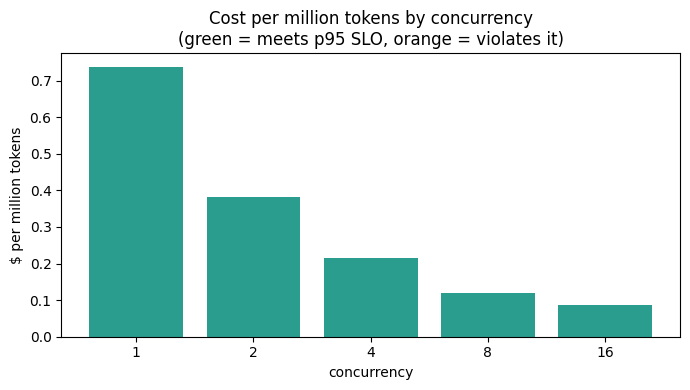

In [7]:
try:
    import matplotlib.pyplot as plt

    concs = [L["concurrency"] for L in levels]
    costs = [L["cost_per_million_tokens_usd"] for L in levels]
    colors = ["#2a9d8f" if L["latency_p95_s"] <= 3.0 else "#e76f51" for L in levels]

    plt.figure(figsize=(7, 4))
    plt.bar([str(c) for c in concs], costs, color=colors)
    plt.xlabel("concurrency")
    plt.ylabel("$ per million tokens")
    plt.title("Cost per million tokens by concurrency\n(green = meets p95 SLO, orange = violates it)")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not installed — skipping plot (run the uv pip cell in Section 0 if you want it).")


In [8]:
TARGET_P95_S = 3.0

under_target = [
    L
    for L in levels
    if L["latency_p95_s"]
       <= TARGET_P95_S
]

knee = max(
    under_target,
    key=lambda L:
        L["concurrency"]
)

print("Safe knee:")
print(knee)


Safe knee:
{'concurrency': 16, 'tokens_per_s': 1107.77, 'latency_p95_s': 1.5057, 'errors': 0, 'cost_per_million_tokens_usd': 0.0878}


In [9]:
def replicas_needed(required_tokens_per_s, knee_tokens_per_s):
    return math.ceil(
        required_tokens_per_s
        / knee_tokens_per_s
    )

K = knee["tokens_per_s"]
print(f"K (knee tokens/s per replica) = {K}")


K (knee tokens/s per replica) = 1107.77


In [11]:
TARGET_MULTIPLES = [1.0, 1.5, 2.0, 3.0]

scale_out_plan = []
for m in TARGET_MULTIPLES:
    R = m * K
    reps = replicas_needed(R, K)
    scale_out_plan.append({
        "target_multiple": m,
        "required_tokens_per_s": R,
        "replicas_needed": reps,
        "total_hourly_cost_usd": round(reps * GPU_HOURLY_USD, 2),
        "effective_p95_s": knee["latency_p95_s"],
    })

header = f"{'multiple':>8} | {'required tok/s':>15} | {'replicas':>8} | {'$/hr':>8} | {'eff. p95 (s)':>12}"
print(header)
for p in scale_out_plan:
    print(f"{p['target_multiple']:>8} | {p['required_tokens_per_s']:>15} | "
          f"{p['replicas_needed']:>8} | {p['total_hourly_cost_usd']:>8} | {p['effective_p95_s']:>12}")

print()
print("Compare: 1 GPU pushed past its knee to try to hit 2x demand would run")
print("at the SLO-violating concurrency levels flagged orange in Section 4 —")
print("that is not a substitute for 2 replicas at the safe knee.")


multiple |  required tok/s | replicas |     $/hr | eff. p95 (s)
     1.0 |         1107.77 |        1 |     0.35 |       1.5057
     1.5 |        1661.655 |        2 |      0.7 |       1.5057
     2.0 |         2215.54 |        2 |      0.7 |       1.5057
     3.0 |         3323.31 |        3 |     1.05 |       1.5057

Compare: 1 GPU pushed past its knee to try to hit 2x demand would run
at the SLO-violating concurrency levels flagged orange in Section 4 —
that is not a substitute for 2 replicas at the safe knee.


In [12]:
cost_report = {
    "gpu_hourly_usd": GPU_HOURLY_USD,
    "target_p95_s": TARGET_P95_S,
    "levels": levels,
    "knee": knee,
    "scale_out_plan": scale_out_plan,
}

with open("cost_report.json", "w") as f:
    json.dump(cost_report, f, indent=2)

print("Wrote cost_report.json")
print(json.dumps(cost_report, indent=2))


Wrote cost_report.json
{
  "gpu_hourly_usd": 0.35,
  "target_p95_s": 3.0,
  "levels": [
    {
      "concurrency": 1,
      "tokens_per_s": 131.73,
      "latency_p95_s": 0.9793,
      "errors": 0,
      "cost_per_million_tokens_usd": 0.738
    },
    {
      "concurrency": 2,
      "tokens_per_s": 254.36,
      "latency_p95_s": 0.9872,
      "errors": 0,
      "cost_per_million_tokens_usd": 0.3822
    },
    {
      "concurrency": 4,
      "tokens_per_s": 454.36,
      "latency_p95_s": 1.0419,
      "errors": 0,
      "cost_per_million_tokens_usd": 0.214
    },
    {
      "concurrency": 8,
      "tokens_per_s": 806.9,
      "latency_p95_s": 1.1129,
      "errors": 0,
      "cost_per_million_tokens_usd": 0.1205
    },
    {
      "concurrency": 16,
      "tokens_per_s": 1107.77,
      "latency_p95_s": 1.5057,
      "errors": 0,
      "cost_per_million_tokens_usd": 0.0878
    }
  ],
  "knee": {
    "concurrency": 16,
    "tokens_per_s": 1107.77,
    "latency_p95_s": 1.5057,
    "errors

In [13]:
#!/usr/bin/env python3
# Green check for the extra W3D5 lab (cost per million tokens, scale-out).
# Run next to cost_report.json:  python verify.py
# Prints exactly one line last: GREEN CHECK: PASS  or  GREEN CHECK: FAIL (<reason>)
# stdlib only.
#
# The lab is pure arithmetic over the student's own bench levels, so this
# recomputes EVERYTHING from the levels in the report: per-level cost, knee
# selection, and the whole scale-out plan. It works identically for the sample
# bench and a student's real one.
import json, math, os
from typing import NoReturn


class _Stop(Exception):
    pass


def _fail(reason) -> NoReturn:
    print("GREEN CHECK: FAIL (%s)" % reason)
    raise _Stop()


def main():
    if not os.path.isfile("cost_report.json"):
        _fail("cost_report.json not found; run Step 5 first")
    try:
        with open("cost_report.json") as f:
            r = json.load(f)
    except json.JSONDecodeError as e:
        _fail("cost_report.json is not valid JSON: %s" % e)

    for key in ("gpu_hourly_usd", "target_p95_s", "levels", "knee", "scale_out_plan"):
        if key not in r:
            _fail("missing key '%s'" % key)
    rate, slo = r["gpu_hourly_usd"], r["target_p95_s"]
    if not isinstance(rate, (int, float)) or rate <= 0:
        _fail("gpu_hourly_usd must be a positive dollars-per-hour figure")
    if not isinstance(slo, (int, float)) or slo <= 0:
        _fail("target_p95_s must be a positive SLO in seconds")

    levels = r["levels"]
    if not isinstance(levels, list) or len(levels) < 3:
        _fail("levels must hold the bench sweep (at least 3 concurrency levels)")
    for L in levels:
        for f_ in ("concurrency", "tokens_per_s", "latency_p95_s",
                   "cost_per_million_tokens_usd"):
            if not isinstance(L.get(f_), (int, float)):
                _fail("level %r lacks numeric %s" % (L.get("concurrency"), f_))
        if not L["tokens_per_s"] or L["tokens_per_s"] <= 0:
            _fail("level %s reports tokens_per_s <= 0 (an all-error level); rerun the sweep" % L.get("concurrency"))
        want_cost = round(rate / (L["tokens_per_s"] * 3600 / 1_000_000), 4)
        if abs(L["cost_per_million_tokens_usd"] - want_cost) > max(0.0002, want_cost * 0.01):
            _fail("concurrency %s: cost %.4f, the formula gives %.4f "
                  "(tokens/s vs tokens/hour, or a non-hourly rate?)"
                  % (L["concurrency"], L["cost_per_million_tokens_usd"], want_cost))

    under = [L for L in levels if L["latency_p95_s"] <= slo]
    if not under:
        _fail("no level sits under the SLO, so no knee exists; the report "
              "should not have gotten this far (see failure modes)")
    want_knee = max(under, key=lambda L: L["concurrency"])
    knee = r["knee"]
    if not isinstance(knee, dict) or knee.get("concurrency") != want_knee["concurrency"]:
        _fail("knee is concurrency %s; the largest level under the %.1fs SLO "
              "is concurrency %s" % ((knee or {}).get("concurrency"), slo,
                                     want_knee["concurrency"]))

    plan = r["scale_out_plan"]
    want_targets = [round(want_knee["tokens_per_s"] * m, 6) for m in (1.0, 1.5, 2.0, 3.0)]
    if not isinstance(plan, list) or len(plan) != 4:
        _fail("scale_out_plan must hold the four multiples 1.0, 1.5, 2.0, 3.0")
    for row, want_req in zip(plan, want_targets):
        req = row.get("required_tokens_per_s")
        if not isinstance(req, (int, float)) or abs(req - want_req) > max(0.5, want_req * 0.01):
            _fail("plan targets must be the knee's throughput x (1, 1.5, 2, 3); "
                  "got %r, expected %.1f" % (req, want_req))
        want_n = math.ceil(want_req / want_knee["tokens_per_s"] - 1e-9)
        if row.get("replicas_needed") != want_n:
            _fail("required %.1f tok/s: replicas_needed=%r, ceil gives %d"
                  % (req, row.get("replicas_needed"), want_n))
        want_cost = round(want_n * rate, 2)
        if abs(row.get("total_hourly_cost_usd", 1e9) - want_cost) > 0.011:
            _fail("required %.1f tok/s: hourly cost %r, %d replicas at %.2f/h "
                  "gives %.2f" % (req, row.get("total_hourly_cost_usd"),
                                  want_n, rate, want_cost))
        if abs(row.get("effective_p95_s", 1e9) - want_knee["latency_p95_s"]) > 0.011:
            _fail("effective_p95_s must stay at the knee's p95: replicas run at "
                  "the safe concurrency, that is the whole model")

    print("recomputed costs, knee and scale-out plan all agree")
    print("GREEN CHECK: PASS")


if __name__ == "__main__":
    try:
        main()
    except _Stop:
        raise SystemExit(1)


recomputed costs, knee and scale-out plan all agree
GREEN CHECK: PASS
